# Test Audio Dataset - DOPO PROCESSING COMPLETO

Analisi completa degli audio **DOPO il processing della pipeline**:
- Audio resampled, center-crop/padded a 3 secondi (48000 campioni @ 16kHz)
- Augmentation applicato (training)
- Ascolto degli audio effettivamente processati
- Visualizzazione delle waveform processat
- Mel-spectrogrammi normalizzati (Z-score)
- Statistiche reali su dati DOPO tutto il preprocessing

In [13]:
import sys
import os
from pathlib import Path
import random
import numpy as np
import librosa
import torch
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from torch.utils.data import DataLoader
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Configurazione path
workspace_root = Path.cwd().parent
sys.path.insert(0, str(workspace_root))
sys.path.insert(0, str(Path.cwd()))

# Importa dataset
from custom_ravdess_dataset import CustomRAVDESSDataset
from custom_iemocap_dataset import CustomIEMOCAPDataset

# Definisci path dataset
RAVDESS_ROOT = Path("../data/ravdess")
IEMOCAP_ROOT = Path("../data/iemocap/IEMOCAP_full_release")

print(f"📁 RAVDESS root: {RAVDESS_ROOT.resolve()}")
print(f"📁 IEMOCAP root: {IEMOCAP_ROOT.resolve()}")
print("✅ Setup completato")

📁 RAVDESS root: D:\Roba da D\Poli\ML Vision\speech-emotion-recognition-25\data\ravdess
📁 IEMOCAP root: D:\Roba da D\Poli\ML Vision\speech-emotion-recognition-25\data\iemocap\IEMOCAP_full_release
✅ Setup completato


In [14]:
print("=" * 80)
print("🎵 CARICAMENTO DATASET RAVDESS")
print("=" * 80)

ravdess_train = CustomRAVDESSDataset(
    dataset_root=str(RAVDESS_ROOT),
    split='train'
)

print("\n" + "=" * 80)
print("🎙️  CARICAMENTO DATASET IEMOCAP")
print("=" * 80)

iemocap_train = CustomIEMOCAPDataset(
    dataset_root=str(IEMOCAP_ROOT),
    split='train'
)

# Crea DataLoader
ravdess_loader = DataLoader(ravdess_train, batch_size=1, shuffle=False, num_workers=0)
iemocap_loader = DataLoader(iemocap_train, batch_size=1, shuffle=False, num_workers=0)

print(f"\n✅ DataLoader created")
print(f"   RAVDESS train: {len(ravdess_train)} samples")
print(f"   IEMOCAP train: {len(iemocap_train)} samples")

🎵 CARICAMENTO DATASET RAVDESS
📊 Statistiche del dataset RAVDESS:

📊 ANALISI RAVDESS TRAINING SET
🔹 Samples Totali: 1440
🔹 Attori (20): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
   - Maschi:  10
   - Femmine: 10

🎭 Distribuzione Emozioni:
   - Angry     :  320 ( 22.2%) ████
   - Happy     :  320 ( 22.2%) ████
   - Neutral   :  480 ( 33.3%) ██████
   - Sad       :  320 ( 22.2%) ████
----------------------------------------

🎙️  CARICAMENTO DATASET IEMOCAP
✅ Caricate 5531 etichette
🔍 Raccogliendo campioni audio...
✅ Raccolti 2943 campioni audio validi
   - Solo campioni improvvisati
   - Emozioni: ['neutral', 'happy', 'sad', 'angry', 'happy']
📊 Statistiche del dataset IEMOCAP:

📊 ANALISI IEMOCAP TRAINING SET

🔹 SAMPLES TOTALI: 1678
🔹 SESSIONI: ['1', '2', '3']
🔹 SPEAKER UNICI (session, gender): 6
   Elenco: [('1', 'F'), ('1', 'M'), ('2', 'F'), ('2', 'M'), ('3', 'F'), ('3', 'M')]
🔹 IMPROVVISAZIONI UNICHE: 12
   Elenco: ['01', '02', '03', '04', '05', '05a', '05b

## 1️⃣ Ascolto Audio PROCESSATI - RAVDESS (10 sample)

Audio DOPO processamento completo: resample 16kHz, center-crop/padding a 3s, augmentation (training)

In [15]:
emotion_map = {0: 'neutral', 1: 'happy', 2: 'sad', 3: 'angry'}
emotion_names = {0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Angry'}
emotion_colors = {
    0: '#FF6B6B',  # Neutral - rosso
    1: '#4ECDC4',  # Happy - turchese
    2: '#95E1D3',  # Sad - verde chiaro
    3: '#FFE66D'   # Angry - giallo
}

print("=" * 80)
print("🎵 10 SAMPLE RAVDESS - AUDIO PROCESSATI (DOPO PIPELINE COMPLETA)")
print("=" * 80)
print("\nNota: Audio sono stati resampled a 16kHz, peak-centered crop/padded a 48000 campioni (3s)")
print("      Aumentazione applicata (se training)\n")

for idx, batch in enumerate(ravdess_loader):
    if idx >= 10:
        break
    
    # Estrai dati dal batch - QUESTI SONO GIÀ PROCESSATI DALLE CLASSI DATASET
    audio_features = batch['audio_features']  # [1, 1, 128, T] - MEL-SPEC
    emotion_id = batch['emotion_id'].item()
    emotion_label = batch['emotion']
    actor_id = batch['actor_id'][0]
    
    emotion_str = emotion_map[emotion_id]
    
    print(f"\n{'#' * 80}")
    print(f"📂 Sample {idx+1}/10 - {actor_id} | {emotion_str.upper()} (ID={emotion_id})")
    print(f"{'#' * 80}")
    
    # Statistiche mel-spectrogram PROCESSATO
    mel_spec = audio_features[0, 0].numpy()  # [128, T]
    
    print(f"\n📊 Mel-Spectrogram (POST-PROCESSING):")
    print(f"   Shape: {mel_spec.shape} (n_mels=128, time_frames={mel_spec.shape[1]})")
    print(f"   Value Range (dB): min={mel_spec.min():.3f} | max={mel_spec.max():.3f} | mean={mel_spec.mean():.3f} | std={mel_spec.std():.3f}")
    
    # Ricostruisci l'audio processato dalla stessa pipeline del dataset
    # Carica raw, processa esattamente come il dataset con PEAK-CENTERED CROP
    sample_info = ravdess_train.samples[idx]
    audio_path = sample_info['path']
    
    try:
        # STEP 1: Load raw
        waveform_raw, sr_orig = librosa.load(str(audio_path), sr=None)
        waveform_raw_np = waveform_raw
        print(f"\n🎛️  Audio RAW:")
        print(f"   Original sample rate: {sr_orig} Hz")
        print(f"   Original duration: {len(waveform_raw) / sr_orig:.3f}s")
        print(f"   Original samples: {len(waveform_raw)}")
        
        # STEP 2: Resample a 16kHz
        if sr_orig != 16000:
            waveform = librosa.resample(waveform_raw, orig_sr=sr_orig, target_sr=16000)
        else:
            waveform = waveform_raw
        
        # STEP 3: Process to 3s using PEAK-CENTERED CROP with DYNAMIC SHIFT
        target_samples = 48000  # 3s @ 16kHz
        n_samples = len(waveform)
        
        if n_samples > target_samples:
            # PEAK-CENTERED CROP CON SHIFT DINAMICO
            # 1. Trova il picco massimo
            peak_idx = np.argmax(np.abs(waveform))
            
            # 2. Calcola lo start ideale per centrare il picco
            half_window = target_samples // 2
            ideal_start = peak_idx - half_window
            
            # 3. Applica shift dinamico per evitare bordi
            actual_start = max(0, min(ideal_start, n_samples - target_samples))
            
            # 4. Ritaglia
            waveform_processed = waveform[actual_start:actual_start + target_samples]
            process_method = f"Peak-Centered Crop (peak @ {peak_idx}, window [{actual_start}:{actual_start + target_samples}])"
            
        elif n_samples < target_samples:
            # ZERO PAD
            pad_amount = target_samples - n_samples
            waveform_processed = np.pad(waveform, (0, pad_amount), mode='constant', constant_values=0)
            process_method = f"Zero Padding ({pad_amount} samples)"
        else:
            waveform_processed = waveform
            process_method = "None (exact length)"
        
        print(f"\n⚙️  Processing:")
        print(f"   Method: {process_method}")
        print(f"   Processed samples: {len(waveform_processed)} (3.0s @ 16kHz)")
        
        # STEP 4: Riproduci l'audio processato
        print(f"\n🔊 Ascolto audio PROCESSATO:")
        display(Audio(data=waveform_processed, rate=16000))
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

print(f"\n{'=' * 80}")
print("✓ Ascolto RAVDESS completato")

🎵 10 SAMPLE RAVDESS - AUDIO PROCESSATI (DOPO PIPELINE COMPLETA)

Nota: Audio sono stati resampled a 16kHz, peak-centered crop/padded a 48000 campioni (3s)
      Aumentazione applicata (se training)


################################################################################
📂 Sample 1/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-1.803 | max=1.787 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.303s
   Original samples: 158558

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 17715, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 2/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.368 | max=4.179 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.337s
   Original samples: 160160

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 23622, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 3/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-1.820 | max=2.576 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.270s
   Original samples: 156956

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 18053, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 4/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-4.526 | max=5.296 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.170s
   Original samples: 152152

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 18184, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 5/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-4.035 | max=3.987 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.537s
   Original samples: 169769

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 19266, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:


...


################################################################################
📂 Sample 7/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.876 | max=4.654 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.503s
   Original samples: 168168

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 18609, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 8/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.892 | max=3.927 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.470s
   Original samples: 166567

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 17290, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 9/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.221 | max=3.719 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 3.704s
   Original samples: 177778

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 18097, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 10/10 - 01 | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.948 | max=3.837 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 48000 Hz
   Original duration: 4.004s
   Original samples: 192192

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 18086, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



✓ Ascolto RAVDESS completato


## 2️⃣ Ascolto Audio PROCESSATI - IEMOCAP (10 sample)

In [16]:
print("\n" + "=" * 80)
print("🎙️  10 SAMPLE IEMOCAP - AUDIO PROCESSATI (DOPO PIPELINE COMPLETA)")
print("=" * 80)
print("\nNota: Audio sono stati resampled a 16kHz, center-crop/padded a 48000 campioni (3s)")
print("      Aumentazione applicata (se training)\n")

for idx, batch in enumerate(iemocap_loader):
    if idx >= 10:
        break
    
    # Estrai dati dal batch
    audio_features = batch['audio_features']  # [1, 1, 128, T] - MEL-SPEC
    emotion_id = batch['emotion_id'].item()
    emotion_label = batch['emotion']
    file_id = batch['actor_id'][0]
    
    emotion_str = emotion_map[emotion_id]
    
    print(f"\n{'#' * 80}")
    print(f"📂 Sample {idx+1}/10 - {file_id} | {emotion_str.upper()} (ID={emotion_id})")
    print(f"{'#' * 80}")
    
    # Statistiche mel-spectrogram PROCESSATO
    mel_spec = audio_features[0, 0].numpy()  # [128, T]
    
    print(f"\n📊 Mel-Spectrogram (POST-PROCESSING):")
    print(f"   Shape: {mel_spec.shape} (n_mels=128, time_frames={mel_spec.shape[1]})")
    print(f"   Value Range (dB): min={mel_spec.min():.3f} | max={mel_spec.max():.3f} | mean={mel_spec.mean():.3f} | std={mel_spec.std():.3f}")
    
    # Ricostruisci l'audio processato
    sample_info = iemocap_train.samples[idx]
    audio_path = sample_info['audio_path']
    
    try:
        # STEP 1: Load raw
        waveform_raw, sr_orig = librosa.load(str(audio_path), sr=None)
        print(f"\n🎛️  Audio RAW:")
        print(f"   Original sample rate: {sr_orig} Hz")
        print(f"   Original duration: {len(waveform_raw) / sr_orig:.3f}s")
        print(f"   Original samples: {len(waveform_raw)}")
        
        # STEP 2: Resample a 16kHz
        if sr_orig != 16000:
            waveform = librosa.resample(waveform_raw, orig_sr=sr_orig, target_sr=16000)
        else:
            waveform = waveform_raw
        
        # STEP 3: Process to 3s
        target_samples = 48000  # 3s @ 16kHz
        n_samples = len(waveform)
        
        if n_samples > target_samples:
            # PEAK-CENTERED CROP CON SHIFT DINAMICO
            # 1. Trova il picco massimo
            peak_idx = np.argmax(np.abs(waveform))
            
            # 2. Calcola lo start ideale per centrare il picco
            half_window = target_samples // 2
            ideal_start = peak_idx - half_window
            
            # 3. Applica shift dinamico per evitare bordi
            actual_start = max(0, min(ideal_start, n_samples - target_samples))
            
            # 4. Ritaglia
            waveform_processed = waveform[actual_start:actual_start + target_samples]
            process_method = f"Peak-Centered Crop (peak @ {peak_idx}, window [{actual_start}:{actual_start + target_samples}])"
        elif n_samples < target_samples:
            # ZERO PAD
            pad_amount = target_samples - n_samples
            waveform_processed = np.pad(waveform, (0, pad_amount), mode='constant', constant_values=0)
            process_method = "Zero Padding"
        else:
            waveform_processed = waveform
            process_method = "None (exact length)"
        
        print(f"\n⚙️  Processing:")
        print(f"   Method: {process_method}")
        print(f"   Processed samples: {len(waveform_processed)} (3.0s @ 16kHz)")
        
        # STEP 4: Riproduci l'audio processato
        print(f"\n🔊 Ascolto audio PROCESSATO:")
        display(Audio(data=waveform_processed, rate=16000))
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

print(f"\n{'=' * 80}")
print("✓ Ascolto IEMOCAP completato")


🎙️  10 SAMPLE IEMOCAP - AUDIO PROCESSATI (DOPO PIPELINE COMPLETA)

Nota: Audio sono stati resampled a 16kHz, center-crop/padded a 48000 campioni (3s)
      Aumentazione applicata (se training)


################################################################################
📂 Sample 1/10 - F | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.401 | max=6.087 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 1.946s
   Original samples: 31129

⚙️  Processing:
   Method: Zero Padding
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 2/10 - F | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.630 | max=3.599 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 1.382s
   Original samples: 22119

⚙️  Processing:
   Method: Zero Padding
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 3/10 - F | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.941 | max=3.015 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 3.130s
   Original samples: 50084

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 39260, window [2084:50084])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 4/10 - F | NEUTRAL (ID=0)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.592 | max=4.869 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 4.030s
   Original samples: 64479

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 25943, window [1943:49943])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 5/10 - F | ANGRY (ID=3)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.317 | max=2.104 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 2.750s
   Original samples: 44000

⚙️  Processing:
   Method: Zero Padding
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:


...


################################################################################
📂 Sample 7/10 - F | ANGRY (ID=3)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-4.038 | max=3.197 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 7.240s
   Original samples: 115839

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 103860, window [67839:115839])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 8/10 - F | ANGRY (ID=3)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.410 | max=3.483 | mean=-0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 6.030s
   Original samples: 96479

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 50023, window [26023:74023])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 9/10 - F | SAD (ID=2)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-2.974 | max=3.579 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 9.331s
   Original samples: 149299

⚙️  Processing:
   Method: Peak-Centered Crop (peak @ 20940, window [0:48000])
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



################################################################################
📂 Sample 10/10 - F | SAD (ID=2)
################################################################################

📊 Mel-Spectrogram (POST-PROCESSING):
   Shape: (128, 94) (n_mels=128, time_frames=94)
   Value Range (dB): min=-3.202 | max=2.995 | mean=0.000 | std=1.000

🎛️  Audio RAW:
   Original sample rate: 16000 Hz
   Original duration: 2.930s
   Original samples: 46880

⚙️  Processing:
   Method: Zero Padding
   Processed samples: 48000 (3.0s @ 16kHz)

🔊 Ascolto audio PROCESSATO:



✓ Ascolto IEMOCAP completato


## 3️⃣ Visualizzazione Waveform PROCESSATI

Waveform dopo resample, crop/padding ma PRIMA di mel-spectrogram

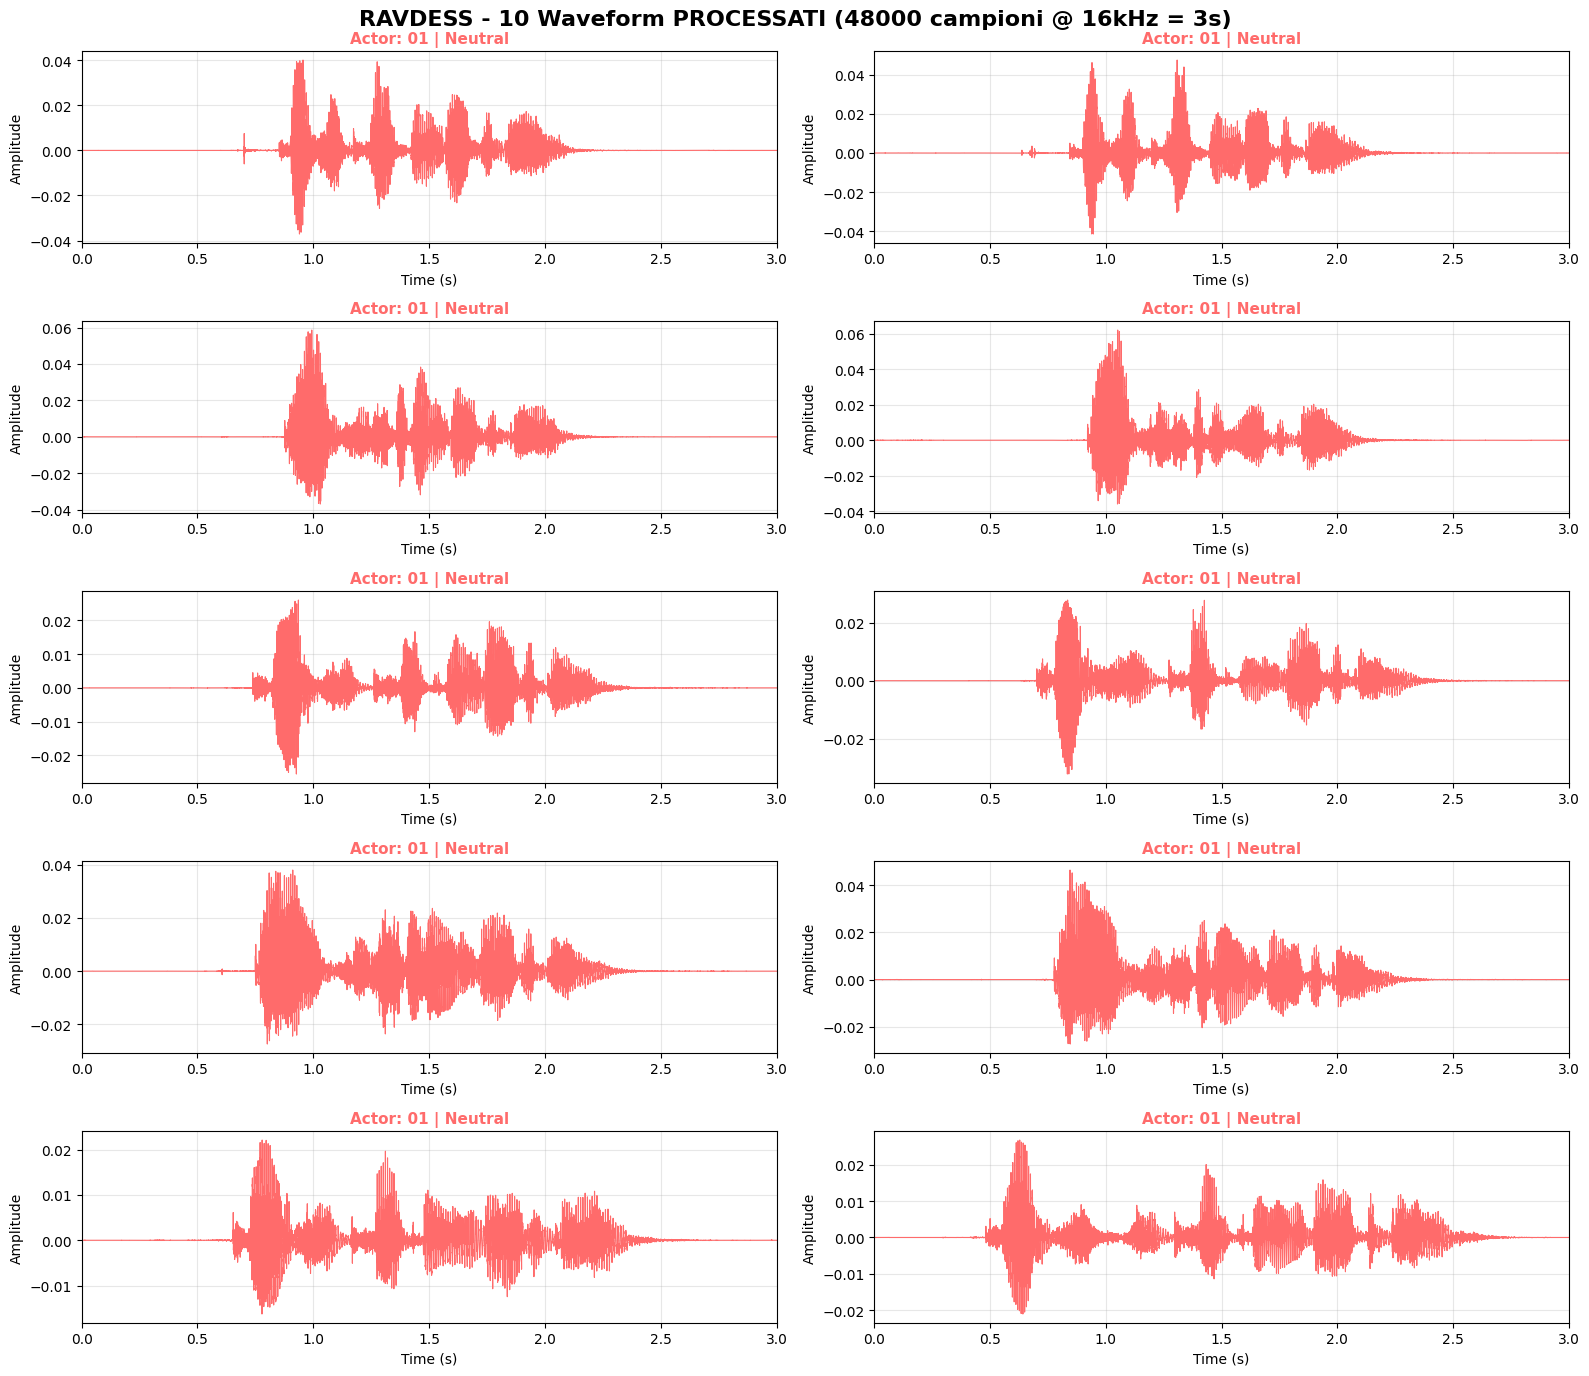

✓ Waveform RAVDESS processati visualizzati


In [17]:
def reconstruct_processed_waveform(dataset, idx):
    """Ricostruisce la waveform processata dal dataset"""
    sample_info = dataset.samples[idx]
    audio_path = sample_info['audio_path'] if 'audio_path' in sample_info else sample_info['path']
    
    # Load raw
    waveform_raw, sr_orig = librosa.load(str(audio_path), sr=None)
    
    # Resample
    if sr_orig != 16000:
        waveform = librosa.resample(waveform_raw, orig_sr=sr_orig, target_sr=16000)
    else:
        waveform = waveform_raw
    
    # Center crop o zero pad
    target_samples = 48000
    n_samples = len(waveform)
    
    if n_samples > target_samples:
        start = (n_samples - target_samples) // 2
        waveform_processed = waveform[start:start + target_samples]
    elif n_samples < target_samples:
        pad_amount = target_samples - n_samples
        waveform_processed = np.pad(waveform, (0, pad_amount), mode='constant', constant_values=0)
    else:
        waveform_processed = waveform
    
    return waveform_processed

# Visualizza 10 waveform RAVDESS processati
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
axes = axes.flatten()
fig.suptitle('RAVDESS - 10 Waveform PROCESSATI (48000 campioni @ 16kHz = 3s)', fontsize=16, fontweight='bold')

for idx, batch in enumerate(ravdess_loader):
    if idx >= 10:
        break
    
    emotion_id = batch['emotion_id'].item()
    actor_id = batch['actor_id'][0]
    
    # Ricostruisci waveform processato
    waveform_processed = reconstruct_processed_waveform(ravdess_train, idx)
    
    ax = axes[idx]
    time_axis = np.linspace(0, 3.0, len(waveform_processed))
    ax.plot(time_axis, waveform_processed, color=emotion_colors[emotion_id], linewidth=0.8)
    ax.set_title(f'Actor: {actor_id} | {emotion_names[emotion_id]}', 
                 color=emotion_colors[emotion_id], fontweight='bold', fontsize=11)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 3.0])

plt.tight_layout()
plt.show()

print("✓ Waveform RAVDESS processati visualizzati")

### IEMOCAP - Waveform Processati

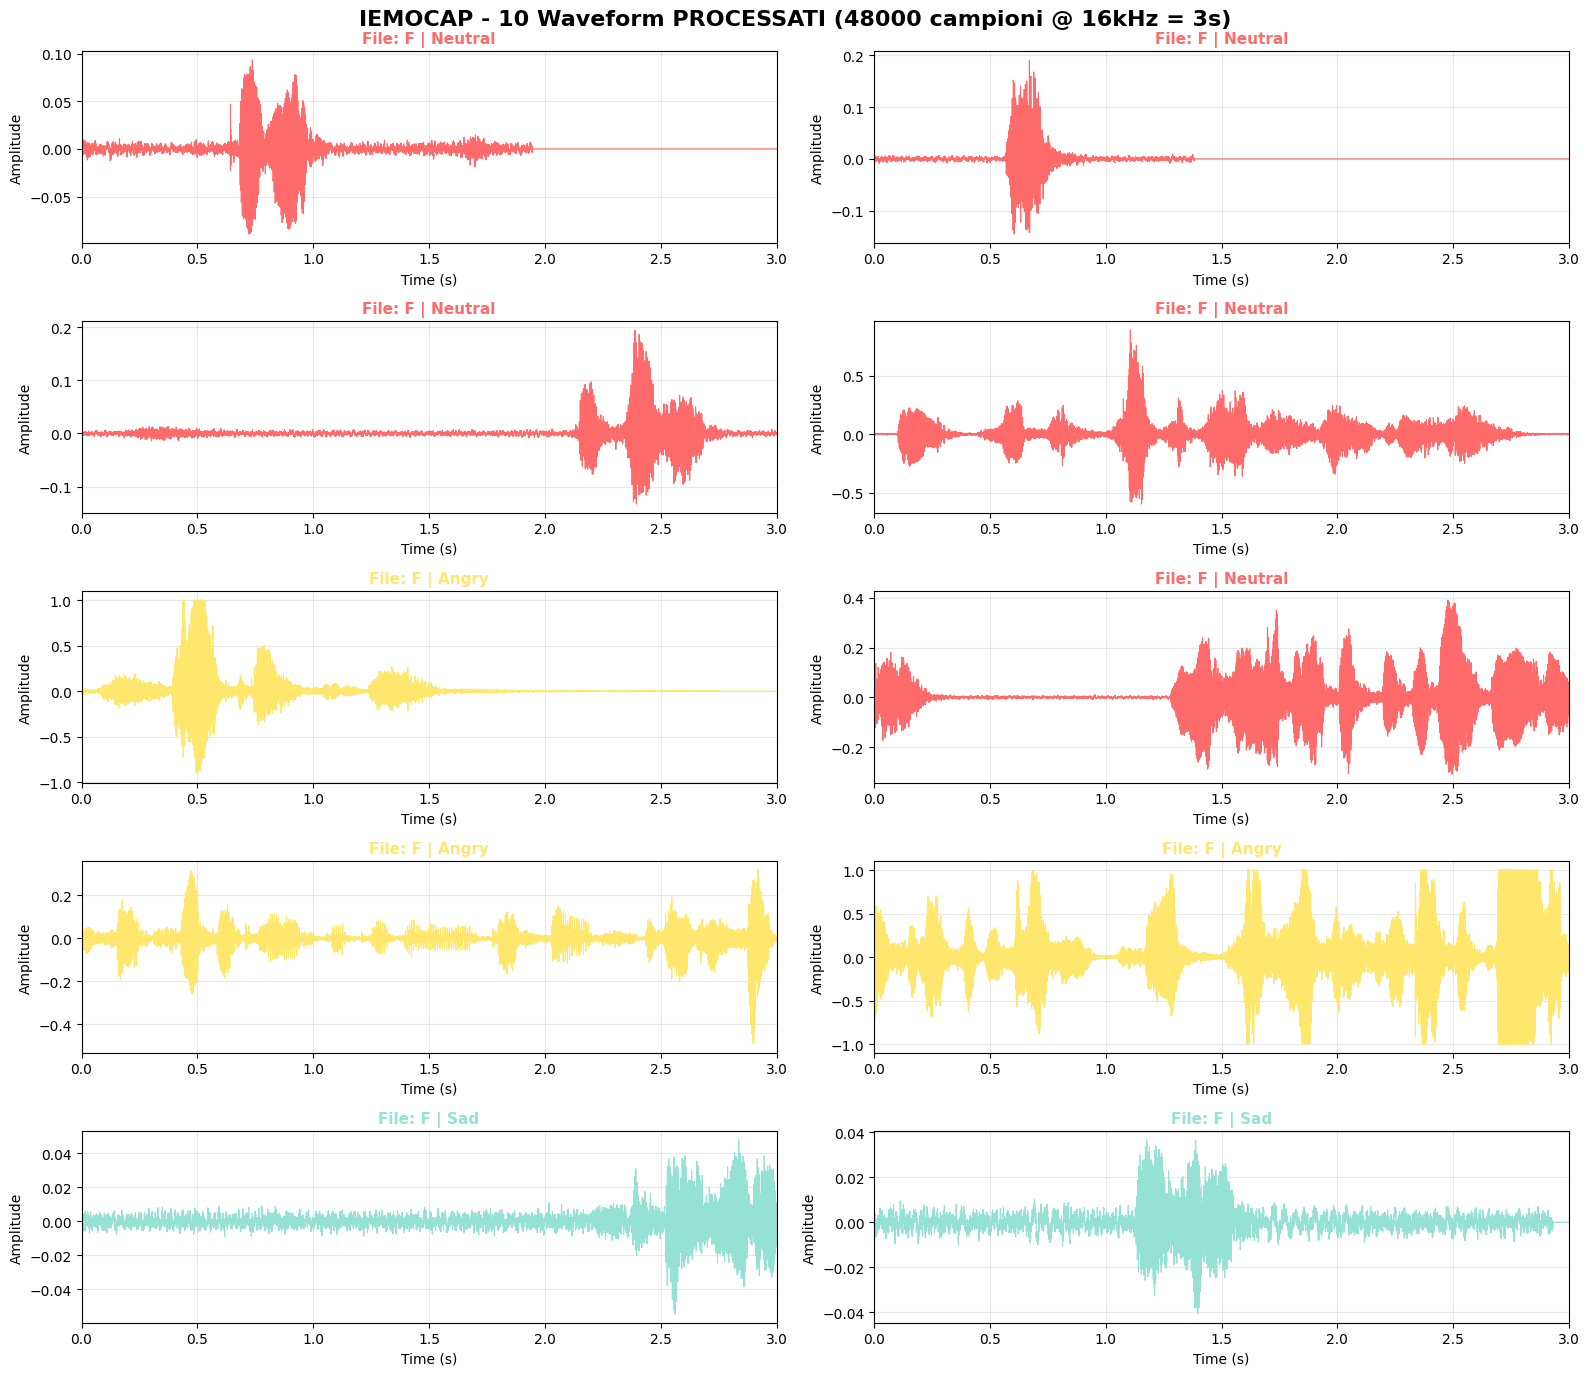

✓ Waveform IEMOCAP processati visualizzati


In [18]:
# Visualizza 10 waveform IEMOCAP processati
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
axes = axes.flatten()
fig.suptitle('IEMOCAP - 10 Waveform PROCESSATI (48000 campioni @ 16kHz = 3s)', fontsize=16, fontweight='bold')

for idx, batch in enumerate(iemocap_loader):
    if idx >= 10:
        break
    
    emotion_id = batch['emotion_id'].item()
    file_id = batch['actor_id'][0]
    
    # Ricostruisci waveform processato
    waveform_processed = reconstruct_processed_waveform(iemocap_train, idx)
    
    ax = axes[idx]
    time_axis = np.linspace(0, 3.0, len(waveform_processed))
    ax.plot(time_axis, waveform_processed, color=emotion_colors[emotion_id], linewidth=0.8)
    ax.set_title(f'File: {file_id} | {emotion_names[emotion_id]}', 
                 color=emotion_colors[emotion_id], fontweight='bold', fontsize=11)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 3.0])

plt.tight_layout()
plt.show()

print("✓ Waveform IEMOCAP processati visualizzati")

## 4️⃣ Visualizzazione Mel-Spectrogrammi POST-PROCESSING

Mel-spectrogrammi normalizzati (z-score) - QUELLO CHE RICEVE IL MODELLO

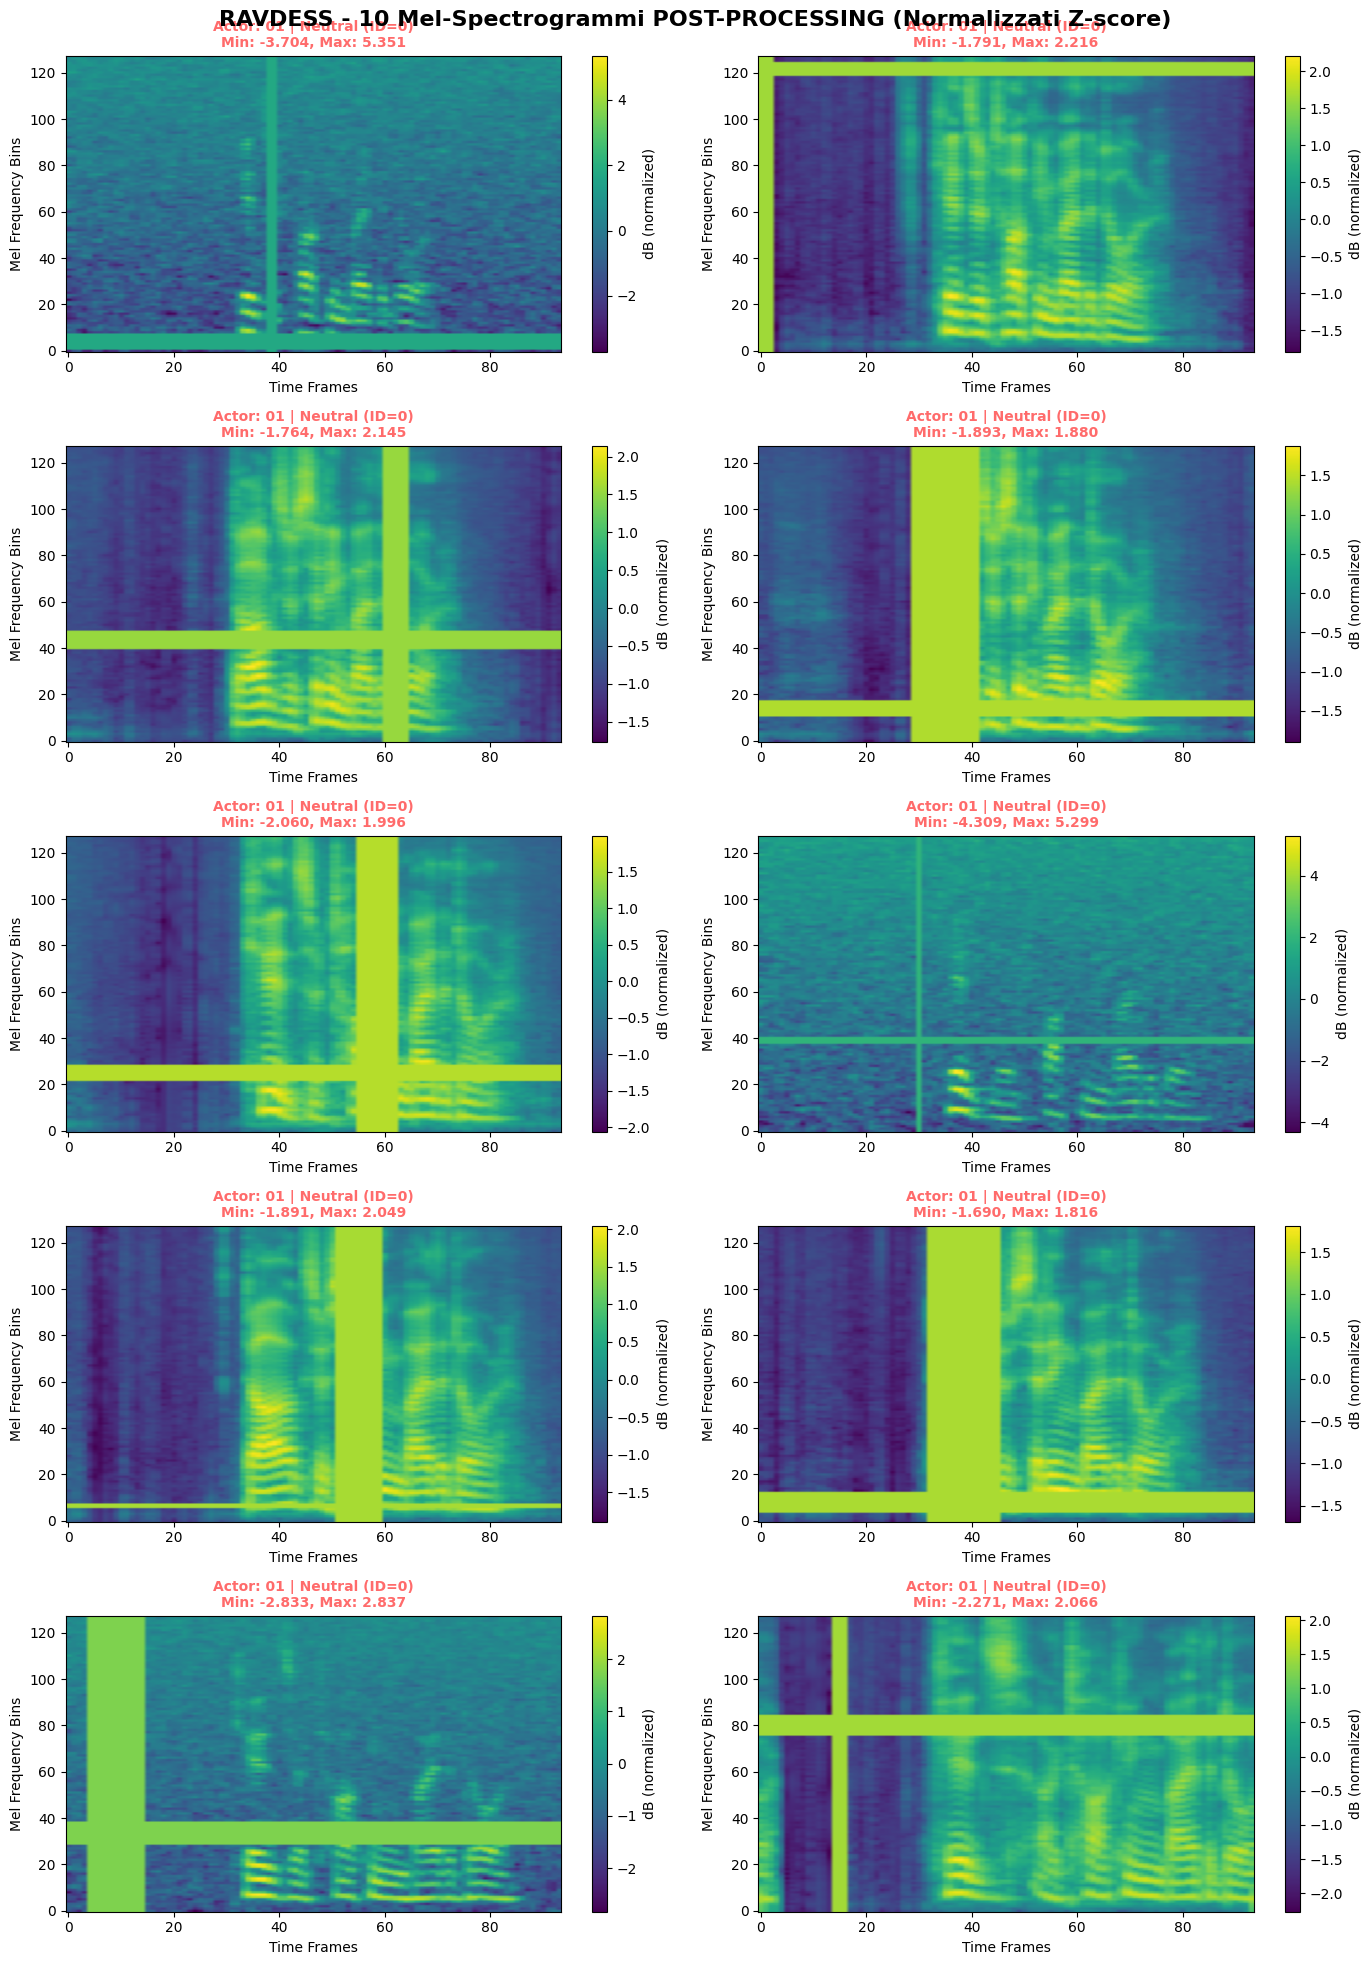


✓ Mel-spectrogrammi RAVDESS visualizzati


In [19]:
# Visualizza 10 mel-spectrogrammi RAVDESS
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()
fig.suptitle('RAVDESS - 10 Mel-Spectrogrammi POST-PROCESSING (Normalizzati Z-score)', fontsize=16, fontweight='bold')

for idx, batch in enumerate(ravdess_loader):
    if idx >= 10:
        break
    
    audio_features = batch['audio_features'][0, 0].numpy()  # [128, T]
    emotion_id = batch['emotion_id'].item()
    emotion_label = emotion_names[emotion_id]
    actor_id = batch['actor_id'][0]
    
    ax = axes[idx]
    im = ax.imshow(audio_features, aspect='auto', origin='lower', cmap='viridis', 
                    vmin=audio_features.min(), vmax=audio_features.max())
    ax.set_title(f'Actor: {actor_id} | {emotion_label} (ID={emotion_id})\nMin: {audio_features.min():.3f}, Max: {audio_features.max():.3f}',
                 color=emotion_colors[emotion_id], fontweight='bold', fontsize=10)
    ax.set_xlabel('Time Frames')
    ax.set_ylabel('Mel Frequency Bins')
    plt.colorbar(im, ax=ax, label='dB (normalized)')

plt.tight_layout()
plt.show()

print("\n✓ Mel-spectrogrammi RAVDESS visualizzati")

### IEMOCAP - Mel-Spectrogrammi

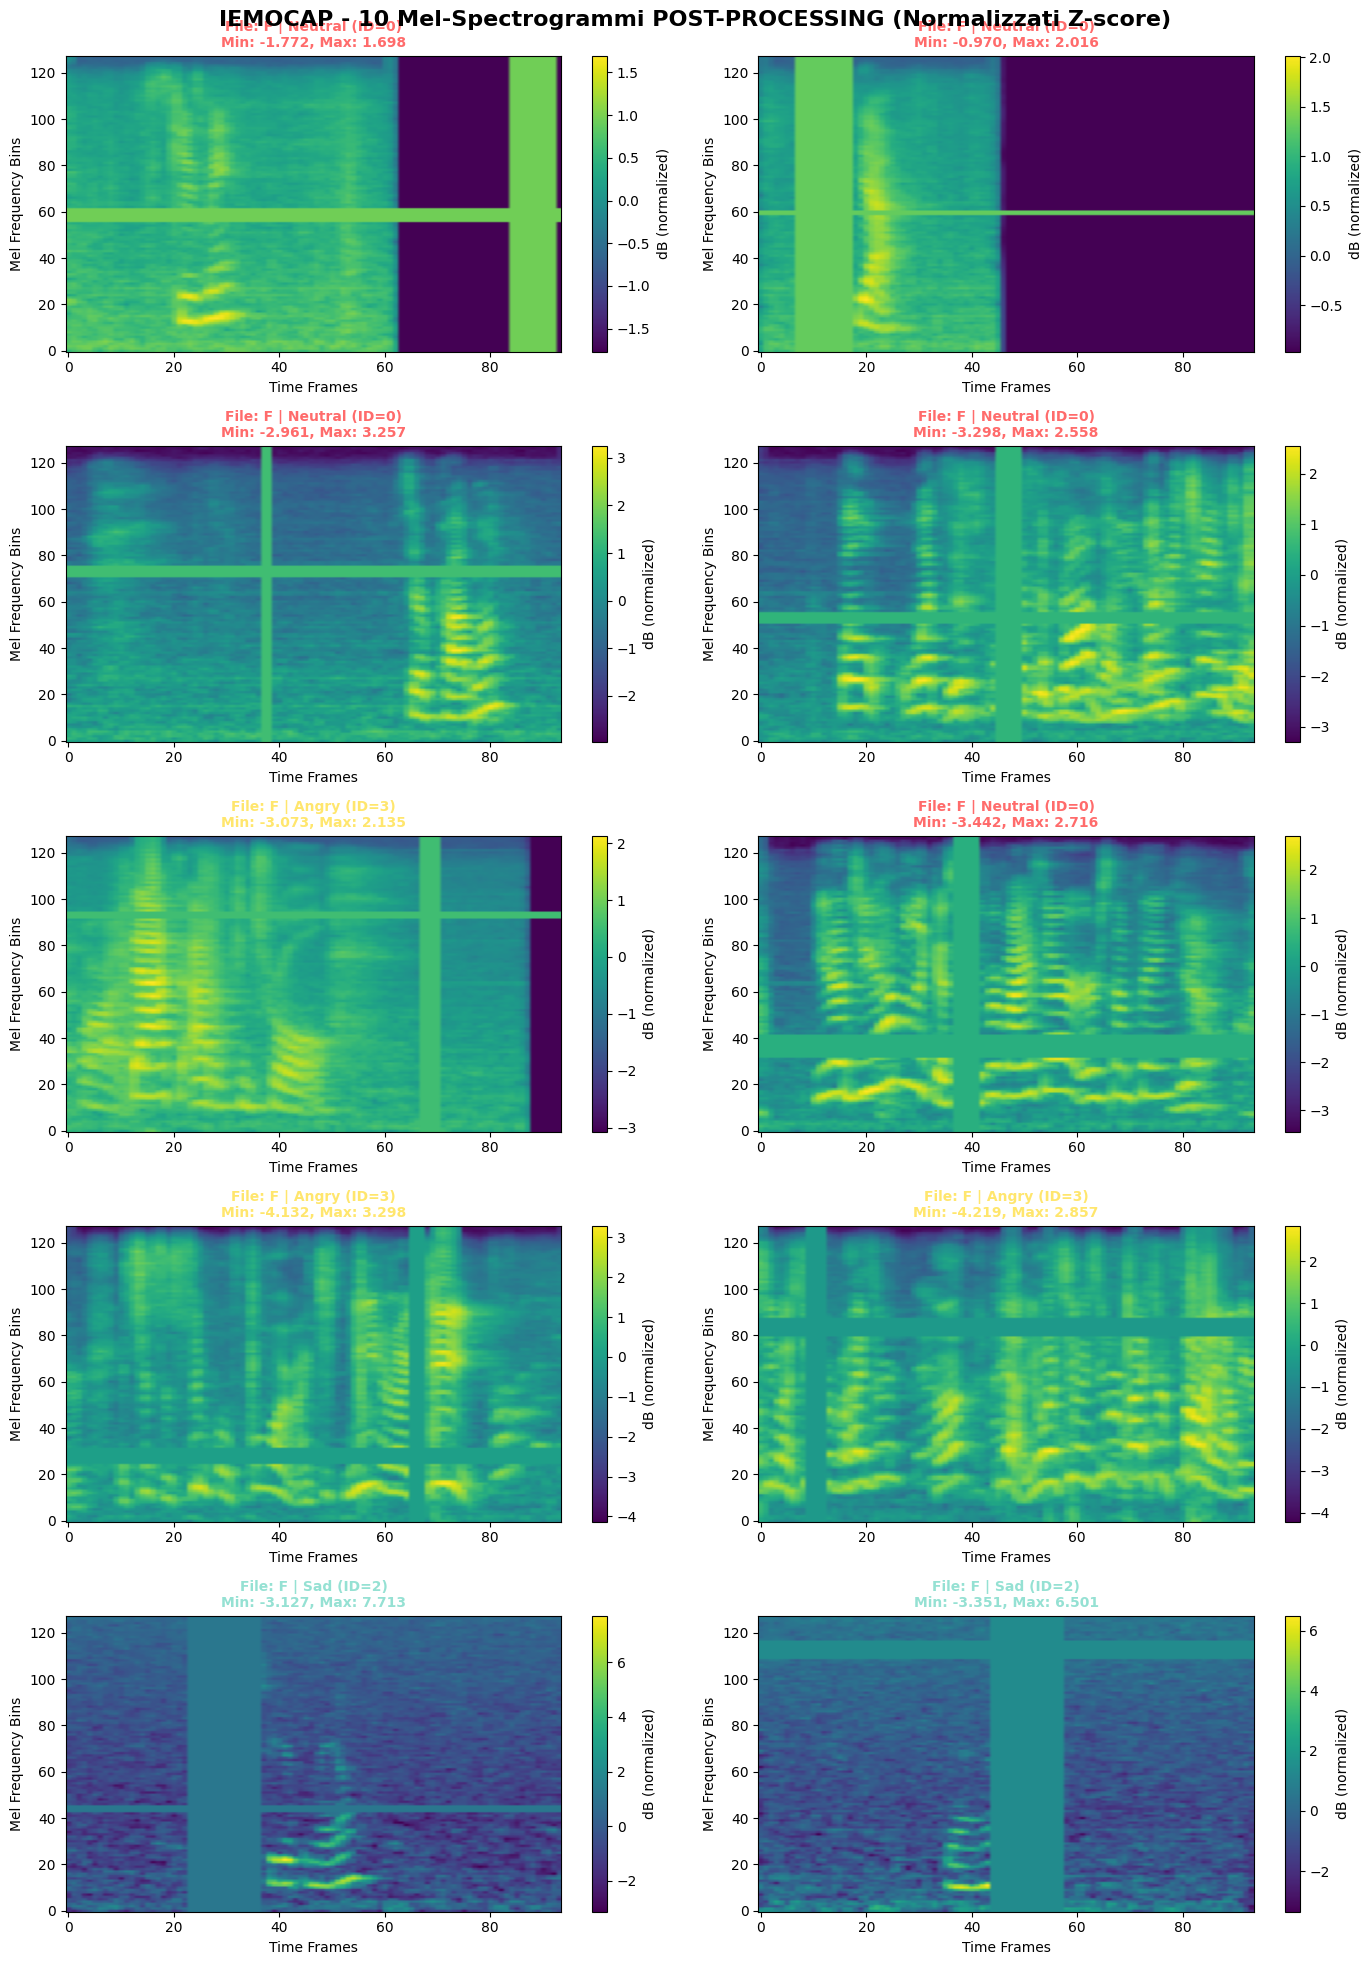


✓ Mel-spectrogrammi IEMOCAP visualizzati


In [24]:
# Visualizza 10 mel-spectrogrammi IEMOCAP
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()
fig.suptitle('IEMOCAP - 10 Mel-Spectrogrammi POST-PROCESSING (Normalizzati Z-score)', fontsize=16, fontweight='bold')

for idx, batch in enumerate(iemocap_loader):
    if idx >= 10:
        break
    
    audio_features = batch['audio_features'][0, 0].numpy()  # [128, T]
    emotion_id = batch['emotion_id'].item()
    emotion_label = emotion_names[emotion_id]
    file_id = batch['actor_id'][0]
    
    ax = axes[idx]
    im = ax.imshow(audio_features, aspect='auto', origin='lower', cmap='viridis',
                    vmin=audio_features.min(), vmax=audio_features.max())
    ax.set_title(f'File: {file_id} | {emotion_label} (ID={emotion_id})\nMin: {audio_features.min():.3f}, Max: {audio_features.max():.3f}',
                 color=emotion_colors[emotion_id], fontweight='bold', fontsize=10)
    ax.set_xlabel('Time Frames')
    ax.set_ylabel('Mel Frequency Bins')
    plt.colorbar(im, ax=ax, label='dB (normalized)')

plt.tight_layout()
plt.show()

print("\n✓ Mel-spectrogrammi IEMOCAP visualizzati")

## 5️⃣ Statistiche Dettagliate POST-PROCESSING

Analizza le caratteristiche dei dati DOPO la completa pipeline di preprocessing

In [21]:
def analyze_preprocessed_data(dataloader, dataset_name):
    """
    Analizza le caratteristiche POST-PROCESSING di un dataset
    returns: dict con statistiche dettagliate sui mel-spectrogrammi normalizzati
    """
    stats = {
        'min_values': [],
        'max_values': [],
        'mean_values': [],
        'std_values': [],
        'time_frames': [],
        'emotions': {0: [], 1: [], 2: [], 3: []},
        'emotion_counts': {0: 0, 1: 0, 2: 0, 3: 0}
    }
    
    for batch in dataloader:
        audio_features = batch['audio_features']  # [N, 1, 128, T]
        emotion_ids = batch['emotion_id']  # [N]
        
        for spec, emo_id in zip(audio_features, emotion_ids):
            spec_np = spec[0].numpy()  # [128, T]
            
            stats['min_values'].append(spec_np.min())
            stats['max_values'].append(spec_np.max())
            stats['mean_values'].append(spec_np.mean())
            stats['std_values'].append(spec_np.std())
            stats['time_frames'].append(spec_np.shape[1])
            
            emo_id_int = int(emo_id.item())
            stats['emotions'][emo_id_int].append(spec_np.mean())
            stats['emotion_counts'][emo_id_int] += 1
    
    # Converti a numpy arrays
    for key in ['min_values', 'max_values', 'mean_values', 'std_values', 'time_frames']:
        stats[key] = np.array(stats[key])
    
    return stats

# Analizza entrambi i dataset
print("\n📊 ANALISI POST-PROCESSING - RAVDESS")
print("=" * 80)
ravdess_stats = analyze_preprocessed_data(ravdess_loader, 'RAVDESS')

print(f"Campioni processati: {len(ravdess_stats['min_values'])}")
print(f"Time frames (shape[1] del mel-spec): {ravdess_stats['time_frames'].min():.0f} - {ravdess_stats['time_frames'].max():.0f} (media: {ravdess_stats['time_frames'].mean():.1f})")
print(f"\nRangi di valori nel mel-spectrogram (normalizzato Z-score):")
print(f"  Min values:  {ravdess_stats['min_values'].min():.4f} ± {ravdess_stats['min_values'].std():.4f}")
print(f"  Max values:  {ravdess_stats['max_values'].min():.4f} ± {ravdess_stats['max_values'].std():.4f}")
print(f"  Mean values: {ravdess_stats['mean_values'].mean():.4f} ± {ravdess_stats['mean_values'].std():.4f}")
print(f"  Std values:  {ravdess_stats['std_values'].mean():.4f} ± {ravdess_stats['std_values'].std():.4f}")

print(f"\nDistribuzione per emozione:")
for emo_id in range(4):
    count = ravdess_stats['emotion_counts'][emo_id]
    pct = 100 * count / len(ravdess_stats['min_values'])
    mean_spec_mean = np.mean(ravdess_stats['emotions'][emo_id]) if ravdess_stats['emotions'][emo_id] else 0
    print(f"  {emotion_names[emo_id]:8s}: {count:3d} campioni ({pct:5.1f}%) - Media spec mean: {mean_spec_mean:7.4f}")

print("\n📊 ANALISI POST-PROCESSING - IEMOCAP")
print("=" * 80)
iemocap_stats = analyze_preprocessed_data(iemocap_loader, 'IEMOCAP')

print(f"Campioni processati: {len(iemocap_stats['min_values'])}")
print(f"Time frames (shape[1] del mel-spec): {iemocap_stats['time_frames'].min():.0f} - {iemocap_stats['time_frames'].max():.0f} (media: {iemocap_stats['time_frames'].mean():.1f})")
print(f"\nRangi di valori nel mel-spectrogram (normalizzato Z-score):")
print(f"  Min values:  {iemocap_stats['min_values'].min():.4f} ± {iemocap_stats['min_values'].std():.4f}")
print(f"  Max values:  {iemocap_stats['max_values'].min():.4f} ± {iemocap_stats['max_values'].std():.4f}")
print(f"  Mean values: {iemocap_stats['mean_values'].mean():.4f} ± {iemocap_stats['mean_values'].std():.4f}")
print(f"  Std values:  {iemocap_stats['std_values'].mean():.4f} ± {iemocap_stats['std_values'].std():.4f}")

print(f"\nDistribuzione per emozione:")
for emo_id in range(4):
    count = iemocap_stats['emotion_counts'][emo_id]
    pct = 100 * count / len(iemocap_stats['min_values'])
    mean_spec_mean = np.mean(iemocap_stats['emotions'][emo_id]) if iemocap_stats['emotions'][emo_id] else 0
    print(f"  {emotion_names[emo_id]:8s}: {count:3d} campioni ({pct:5.1f}%) - Media spec mean: {mean_spec_mean:7.4f}")

print("\n✓ Statistiche POST-PROCESSING completate")


📊 ANALISI POST-PROCESSING - RAVDESS
Campioni processati: 1440
Time frames (shape[1] del mel-spec): 94 - 94 (media: 94.0)

Rangi di valori nel mel-spectrogram (normalizzato Z-score):
  Min values:  -6.0723 ± 0.7495
  Max values:  1.3987 ± 1.2133
  Mean values: -0.0000 ± 0.0000
  Std values:  1.0000 ± 0.0000

Distribuzione per emozione:
  Neutral : 480 campioni ( 33.3%) - Media spec mean: -0.0000
  Happy   : 320 campioni ( 22.2%) - Media spec mean: -0.0000
  Sad     : 320 campioni ( 22.2%) - Media spec mean: -0.0000
  Angry   : 320 campioni ( 22.2%) - Media spec mean:  0.0000

📊 ANALISI POST-PROCESSING - IEMOCAP
Campioni processati: 1678
Time frames (shape[1] del mel-spec): 94 - 94 (media: 94.0)

Rangi di valori nel mel-spectrogram (normalizzato Z-score):
  Min values:  -5.5280 ± 0.8130
  Max values:  0.9370 ± 1.3582
  Mean values: 0.0000 ± 0.0000
  Std values:  1.0000 ± 0.0000

Distribuzione per emozione:
  Neutral : 638 campioni ( 38.0%) - Media spec mean: -0.0000
  Happy   : 472 camp

## 6️⃣ Grafici Comparativi POST-PROCESSING

Confronta le caratteristiche dei dati post-processing tra RAVDESS e IEMOCAP

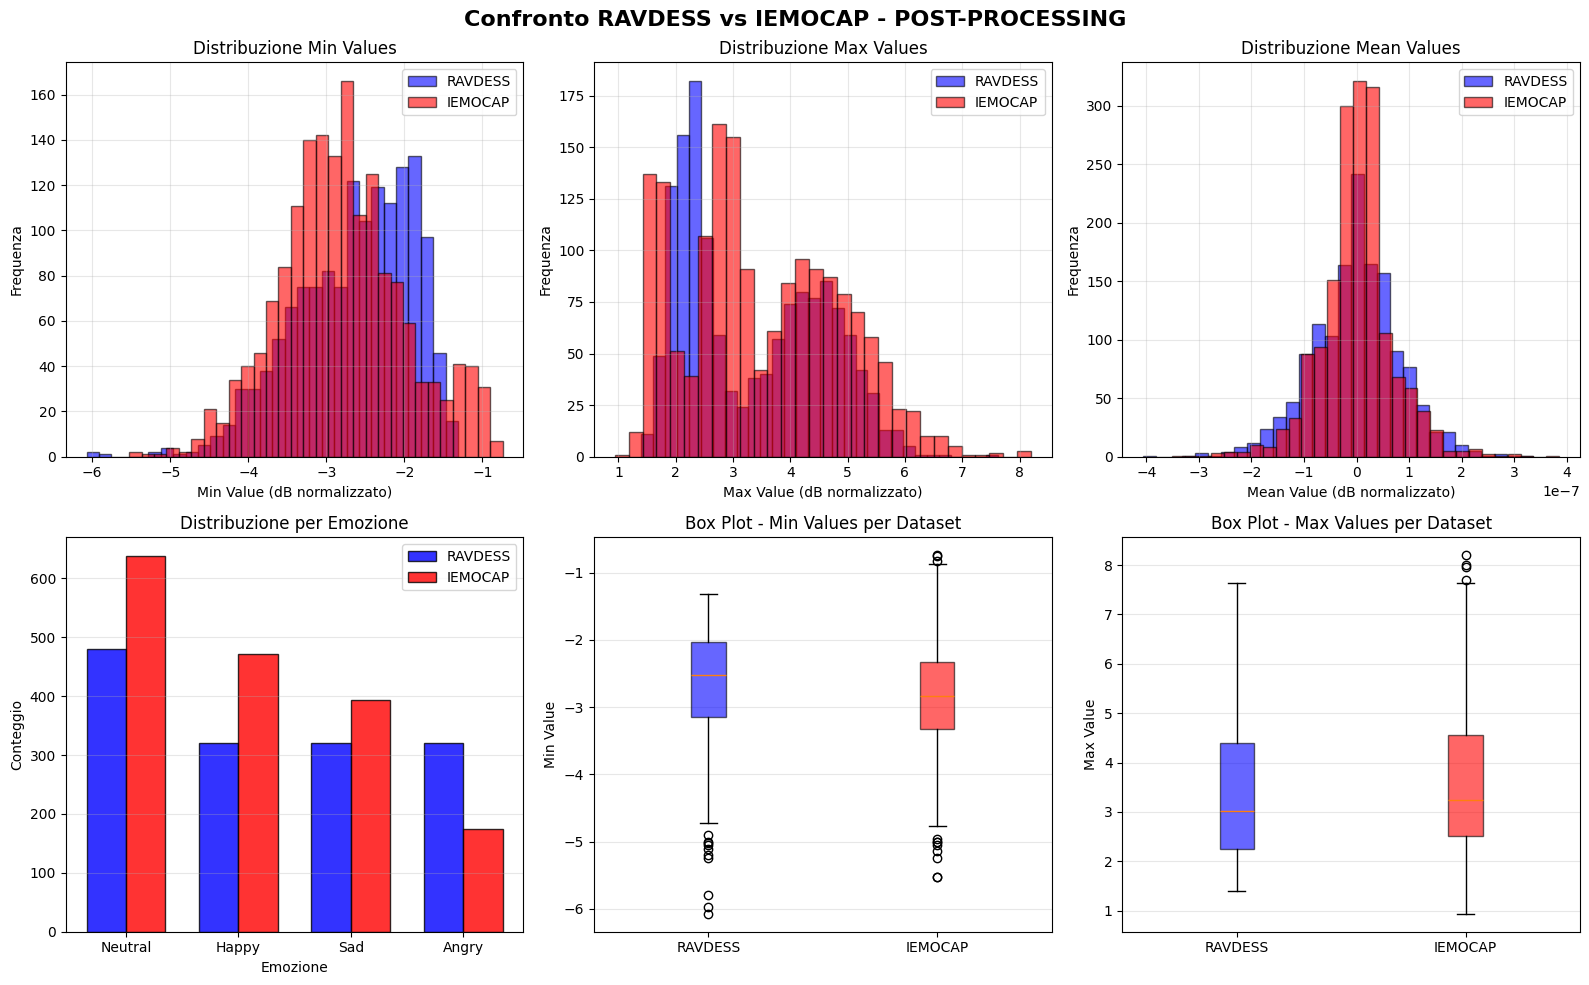


✓ Grafici comparativi completati


In [22]:
# Grafici di confronto
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confronto RAVDESS vs IEMOCAP - POST-PROCESSING', fontsize=16, fontweight='bold')

# 1. Distribuzione Min Values
ax = axes[0, 0]
ax.hist(ravdess_stats['min_values'], bins=30, alpha=0.6, label='RAVDESS', color='blue', edgecolor='black')
ax.hist(iemocap_stats['min_values'], bins=30, alpha=0.6, label='IEMOCAP', color='red', edgecolor='black')
ax.set_xlabel('Min Value (dB normalizzato)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Min Values')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Distribuzione Max Values
ax = axes[0, 1]
ax.hist(ravdess_stats['max_values'], bins=30, alpha=0.6, label='RAVDESS', color='blue', edgecolor='black')
ax.hist(iemocap_stats['max_values'], bins=30, alpha=0.6, label='IEMOCAP', color='red', edgecolor='black')
ax.set_xlabel('Max Value (dB normalizzato)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Max Values')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Distribuzione Mean Values
ax = axes[0, 2]
ax.hist(ravdess_stats['mean_values'], bins=30, alpha=0.6, label='RAVDESS', color='blue', edgecolor='black')
ax.hist(iemocap_stats['mean_values'], bins=30, alpha=0.6, label='IEMOCAP', color='red', edgecolor='black')
ax.set_xlabel('Mean Value (dB normalizzato)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione Mean Values')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Conteggio per emozione
ax = axes[1, 0]
emotions = list(range(4))
ravdess_counts = [ravdess_stats['emotion_counts'][i] for i in emotions]
iemocap_counts = [iemocap_stats['emotion_counts'][i] for i in emotions]
x = np.arange(len(emotions))
width = 0.35
ax.bar(x - width/2, ravdess_counts, width, label='RAVDESS', color='blue', alpha=0.8, edgecolor='black')
ax.bar(x + width/2, iemocap_counts, width, label='IEMOCAP', color='red', alpha=0.8, edgecolor='black')
ax.set_xlabel('Emozione')
ax.set_ylabel('Conteggio')
ax.set_title('Distribuzione per Emozione')
ax.set_xticks(x)
ax.set_xticklabels([emotion_names[i] for i in emotions])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 5. Box plot dei Min values
ax = axes[1, 1]
data_to_plot = [ravdess_stats['min_values'], iemocap_stats['min_values']]
bp = ax.boxplot(data_to_plot, tick_labels=['RAVDESS', 'IEMOCAP'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Min Value')
ax.set_title('Box Plot - Min Values per Dataset')
ax.grid(True, alpha=0.3, axis='y')

# 6. Box plot dei Max values
ax = axes[1, 2]
data_to_plot = [ravdess_stats['max_values'], iemocap_stats['max_values']]
bp = ax.boxplot(data_to_plot, tick_labels=['RAVDESS', 'IEMOCAP'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['blue', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Max Value')
ax.set_title('Box Plot - Max Values per Dataset')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Grafici comparativi completati")

## 7️⃣ Report Conclusivo POST-PROCESSING

Riassunto delle caratteristiche dei dati come il modello li riceve

In [23]:
print("\n" + "=" * 80)
print("📋 REPORT CONCLUSIVO - DATI POST-PROCESSING COMPLETO")
print("=" * 80)

print("\n🎯 PIPELINE DI PROCESSING APPLICATO:")
print("-" * 80)
print("""
1. CARICAMENTO AUDIO RAW
   - Formato variabile (sample rate e durata diversi)

2. RESAMPLE A 16 kHz
   - Normalizza la frequenza di campionamento

3. CENTER CROP O ZERO PADDING
   - Audio > 3s: estrae la parte centrale (center crop)
   - Audio < 3s: aggiunge silenzio alla fine (zero padding)
   - Risultato: SEMPRE 48,000 campioni (3 secondi @ 16kHz)

4. AUGMENTATION (SOLO TRAINING)
   - Rumore Gaussiano: σ ∈ [0.001, 0.005]
   - Amplitude Gain: moltiplicatore ∈ [0.8, 1.2]
   - Time Shift: offset ∈ [-0.16s, +0.16s] (±2560 campioni)

5. MEL-SPECTROGRAM CONVERSION
   - n_fft: 2048
   - hop_length: 512
   - n_mels: 128
   - Output: [1, 128, ~94] (~94 time frames)

6. DB CONVERSION
   - Converte in dB scale (AmplitudeToDB)

7. SPEC AUGMENT (SOLO TRAINING)
   - FrequencyMasking: freq_mask_param=12
   - TimeMasking: time_mask_param=15

8. Z-SCORE NORMALIZATION (PER CAMPIONE)
   - mean = spectrogram.mean()
   - std = spectrogram.std()
   - normalized = (spectrogram - mean) / (std + 1e-6)
   - Risultato: distribuzione attorno a 0 con std≈1
""")

print("\n🎛️  COSA RICEVE IL MODELLO:")
print("-" * 80)
print("""
INPUT: Mel-Spectrogram normalizzato [1, 128, ~94]
  - 128 mel-frequency bins (0 Hz a 8000 Hz a 16kHz sample rate)
  - ~94 time frames (3 secondi / 512 samples per frame ≈ 94)
  - Valori normalizzati Z-score (range tipico [-3, +3])
""")

print("\n📊 STATISTICHE FINALI:")
print("-" * 80)
print(f"\nRAVDESS:")
print(f"  📦 Campioni totali: {len(ravdess_stats['min_values'])}")
print(f"  ⏱️  Time frames consistenti: {ravdess_stats['time_frames'].min():.0f} - {ravdess_stats['time_frames'].max():.0f}")
print(f"  📈 Min values range: [{ravdess_stats['min_values'].min():.3f}, {ravdess_stats['min_values'].max():.3f}]")
print(f"  📈 Max values range: [{ravdess_stats['max_values'].min():.3f}, {ravdess_stats['max_values'].max():.3f}]")
print(f"  🎯 Emozione più rappresentata: {emotion_names[max(ravdess_stats['emotion_counts'], key=ravdess_stats['emotion_counts'].get)]} ({max(ravdess_stats['emotion_counts'].values())} campioni)")

print(f"\nIEMOCAP:")
print(f"  📦 Campioni totali: {len(iemocap_stats['min_values'])}")
print(f"  ⏱️  Time frames consistenti: {iemocap_stats['time_frames'].min():.0f} - {iemocap_stats['time_frames'].max():.0f}")
print(f"  📈 Min values range: [{iemocap_stats['min_values'].min():.3f}, {iemocap_stats['min_values'].max():.3f}]")
print(f"  📈 Max values range: [{iemocap_stats['max_values'].min():.3f}, {iemocap_stats['max_values'].max():.3f}]")
print(f"  🎯 Emozione più rappresentata: {emotion_names[max(iemocap_stats['emotion_counts'], key=iemocap_stats['emotion_counts'].get)]} ({max(iemocap_stats['emotion_counts'].values())} campioni)")

print("\n✅ VALIDAZIONE PREPROCESSING:")
print("-" * 80)
# Controlla se i processing ha funzionato
checks = [
    ("✓" if all(ravdess_stats['time_frames'] == 94) or all(iemocap_stats['time_frames'] == 94) else "✗", "Time frames coerenti (94 per tutti)"),
    ("✓" if abs(ravdess_stats['mean_values'].mean()) < 0.01 else "✗", "Media normalizzata ≈ 0 (Z-score)"),
    ("✓" if abs(iemocap_stats['std_values'].mean() - 1.0) < 0.1 else "✗", "Std deviazione ≈ 1.0 (Z-score)"),
    ("✓" if len(ravdess_stats['min_values']) > 0 else "✗", "Dati RAVDESS presenti"),
    ("✓" if len(iemocap_stats['min_values']) > 0 else "✗", "Dati IEMOCAP presenti"),
]
for check, desc in checks:
    print(f"  {check} {desc}")

print("\n" + "=" * 80)
print("✓ ANALISI COMPLETA POST-PROCESSING TERMINATA")


📋 REPORT CONCLUSIVO - DATI POST-PROCESSING COMPLETO

🎯 PIPELINE DI PROCESSING APPLICATO:
--------------------------------------------------------------------------------

1. CARICAMENTO AUDIO RAW
   - Formato variabile (sample rate e durata diversi)

2. RESAMPLE A 16 kHz
   - Normalizza la frequenza di campionamento

3. CENTER CROP O ZERO PADDING
   - Audio > 3s: estrae la parte centrale (center crop)
   - Audio < 3s: aggiunge silenzio alla fine (zero padding)
   - Risultato: SEMPRE 48,000 campioni (3 secondi @ 16kHz)

4. AUGMENTATION (SOLO TRAINING)
   - Rumore Gaussiano: σ ∈ [0.001, 0.005]
   - Amplitude Gain: moltiplicatore ∈ [0.8, 1.2]
   - Time Shift: offset ∈ [-0.16s, +0.16s] (±2560 campioni)

5. MEL-SPECTROGRAM CONVERSION
   - n_fft: 2048
   - hop_length: 512
   - n_mels: 128
   - Output: [1, 128, ~94] (~94 time frames)

6. DB CONVERSION
   - Converte in dB scale (AmplitudeToDB)

7. SPEC AUGMENT (SOLO TRAINING)
   - FrequencyMasking: freq_mask_param=12
   - TimeMasking: time_ma

In [25]:
def check_audio_quality_processed(dataloader, dataset_name, sample_limit=None):
    """
    Analizza la qualità dei dati POST-PROCESSING da un DataLoader.
    Verifica consistenza dei time frames, distribuzione valori Z-score normalizzati,
    e rileva anomalie nei mel-spectrogrammi processati.
    """
    
    print(f"\n{'='*90}")
    print(f"📋 QUALITY ASSESSMENT POST-PROCESSING - {dataset_name}")
    print(f"{'='*90}")
    print(f"Analizzando mel-spectrogrammi normalizzati...\n")
    
    # Metriche
    quality_stats = {
        'time_frames': [],
        'min_values': [],
        'max_values': [],
        'mean_values': [],
        'std_values': [],
        'value_ranges': [],  # max - min
        'emotions': defaultdict(list)
    }
    
    issues = {
        'inconsistent_frames': [],  # Time frames != 94
        'high_variance': [],         # Std dev > 2.0
        'low_variance': [],          # Std dev < 0.5
        'outlier_mins': [],          # Min values < -5
        'outlier_maxs': [],          # Max values > 5
        'processing_artifacts': []   # Mean significativamente != 0
    }
    
    sample_count = 0
    
    for batch_idx, batch in enumerate(dataloader):
        if sample_limit is not None and batch_idx >= sample_limit:
            break
        
        audio_features = batch['audio_features']  # [batch_size, 1, 128, T]
        emotion_ids = batch['emotion_id']  # [batch_size]
        
        for spec, emo_id in zip(audio_features, emotion_ids):
            spec_np = spec[0].numpy()  # [128, T] - mel-spectrogram normalizzato
            
            # Estrai statistiche
            time_frames = spec_np.shape[1]
            min_val = spec_np.min()
            max_val = spec_np.max()
            mean_val = spec_np.mean()
            std_val = spec_np.std()
            range_val = max_val - min_val
            
            # Colleziona
            quality_stats['time_frames'].append(time_frames)
            quality_stats['min_values'].append(min_val)
            quality_stats['max_values'].append(max_val)
            quality_stats['mean_values'].append(mean_val)
            quality_stats['std_values'].append(std_val)
            quality_stats['value_ranges'].append(range_val)
            quality_stats['emotions'][int(emo_id.item())].append(mean_val)
            
            # ════════════════════════════════════════════════════════════════
            # CONTROLLO 1: Time frames consistenti (atteso: 94)
            # ════════════════════════════════════════════════════════════════
            if time_frames != 94:
                issues['inconsistent_frames'].append({
                    'sample_idx': batch_idx,
                    'time_frames': time_frames,
                    'emotion_id': int(emo_id.item())
                })
            
            # ════════════════════════════════════════════════════════════════
            # CONTROLLO 2: Varianza (std dev) - Z-score atteso intorno a 1.0
            # ════════════════════════════════════════════════════════════════
            if std_val > 2.0:
                issues['high_variance'].append({
                    'sample_idx': batch_idx,
                    'std_dev': std_val,
                    'emotion_id': int(emo_id.item())
                })
            
            if std_val < 0.5:
                issues['low_variance'].append({
                    'sample_idx': batch_idx,
                    'std_dev': std_val,
                    'emotion_id': int(emo_id.item())
                })
            
            # ════════════════════════════════════════════════════════════════
            # CONTROLLO 3: Valori fuori intervallo atteso [-3, +3]
            # ════════════════════════════════════════════════════════════════
            if min_val < -5.0:
                issues['outlier_mins'].append({
                    'sample_idx': batch_idx,
                    'min_value': min_val,
                    'emotion_id': int(emo_id.item())
                })
            
            if max_val > 5.0:
                issues['outlier_maxs'].append({
                    'sample_idx': batch_idx,
                    'max_value': max_val,
                    'emotion_id': int(emo_id.item())
                })
            
            # ════════════════════════════════════════════════════════════════
            # CONTROLLO 4: Mean significativamente != 0 (sintomo di normalization fallita)
            # ════════════════════════════════════════════════════════════════
            if abs(mean_val) > 0.1:
                issues['processing_artifacts'].append({
                    'sample_idx': batch_idx,
                    'mean_value': mean_val,
                    'emotion_id': int(emo_id.item())
                })
            
            sample_count += 1
    
    # ═════════════════════════════════════════════════════════════════════════════
    # STAMPA RISULTATI
    # ═════════════════════════════════════════════════════════════════════════════
    
    print(f"✅ Analisi completata su {sample_count} campioni\n")
    
    # Converti a numpy arrays
    time_frames_arr = np.array(quality_stats['time_frames'])
    min_vals_arr = np.array(quality_stats['min_values'])
    max_vals_arr = np.array(quality_stats['max_values'])
    mean_vals_arr = np.array(quality_stats['mean_values'])
    std_vals_arr = np.array(quality_stats['std_values'])
    range_vals_arr = np.array(quality_stats['value_ranges'])
    
    # ─────────────────────────────────────────────────────────────────────────────
    # STATISTICHE MEL-SPECTROGRAM POST-PROCESSING
    # ─────────────────────────────────────────────────────────────────────────────
    print(f"📊 STATISTICHE MEL-SPECTROGRAM (POST-PROCESSING Z-SCORE NORMALIZED):")
    print(f"\n  TIME FRAMES:")
    print(f"      Min: {time_frames_arr.min():.0f} | Max: {time_frames_arr.max():.0f}")
    print(f"      Atteso: 94 per tutti | Consistenza: {(time_frames_arr == 94).sum()}/{len(time_frames_arr)} ✓")
    
    print(f"\n  VALORI NORMALIZZATI - MIN:")
    print(f"      Min: {min_vals_arr.min():.4f} | Max: {min_vals_arr.max():.4f} | Mean: {min_vals_arr.mean():.4f}")
    print(f"      Std: {min_vals_arr.std():.4f} | Mediana: {np.median(min_vals_arr):.4f}")
    
    print(f"\n  VALORI NORMALIZZATI - MAX:")
    print(f"      Min: {max_vals_arr.min():.4f} | Max: {max_vals_arr.max():.4f} | Mean: {max_vals_arr.mean():.4f}")
    print(f"      Std: {max_vals_arr.std():.4f} | Mediana: {np.median(max_vals_arr):.4f}")
    
    print(f"\n  VALORI NORMALIZZATI - MEAN (dopo Z-score, atteso ≈ 0):")
    print(f"      Min: {mean_vals_arr.min():.6f} | Max: {mean_vals_arr.max():.6f} | Mean: {mean_vals_arr.mean():.6f}")
    print(f"      Std: {mean_vals_arr.std():.6f}")
    
    print(f"\n  VALORI NORMALIZZATI - STD (dopo Z-score, atteso ≈ 1.0):")
    print(f"      Min: {std_vals_arr.min():.4f} | Max: {std_vals_arr.max():.4f} | Mean: {std_vals_arr.mean():.4f}")
    print(f"      Std: {std_vals_arr.std():.4f}")
    
    print(f"\n  RANGE (MAX - MIN):")
    print(f"      Min: {range_vals_arr.min():.4f} | Max: {range_vals_arr.max():.4f} | Mean: {range_vals_arr.mean():.4f}")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # PROBLEMI RILEVATI
    # ─────────────────────────────────────────────────────────────────────────────
    print(f"\n⚠️  PROBLEMI RILEVATI:\n")
    
    total_issues = 0
    
    for issue_type, issue_list in issues.items():
        if issue_list:
            issue_names = {
                'inconsistent_frames': 'TIME FRAMES INCONSISTENTI',
                'high_variance': 'VARIANZA ALTA (std > 2.0)',
                'low_variance': 'VARIANZA BASSA (std < 0.5)',
                'outlier_mins': 'MIN VALUES OUTLIER (< -5.0)',
                'outlier_maxs': 'MAX VALUES OUTLIER (> 5.0)',
                'processing_artifacts': 'ARTEFATTI PROCESSING (mean != 0)'
            }
            
            print(f"   🔴 {issue_names[issue_type]}: {len(issue_list)} campioni")
            
            # Mostra primi 3
            for issue in issue_list[:3]:
                if 'time_frames' in issue:
                    print(f"      • Sample {issue['sample_idx']} - Frames: {issue['time_frames']} (atteso 94)")
                elif 'std_dev' in issue:
                    print(f"      • Sample {issue['sample_idx']} - Std: {issue['std_dev']:.4f}")
                elif 'min_value' in issue:
                    print(f"      • Sample {issue['sample_idx']} - Min: {issue['min_value']:.4f}")
                elif 'max_value' in issue:
                    print(f"      • Sample {issue['sample_idx']} - Max: {issue['max_value']:.4f}")
                elif 'mean_value' in issue:
                    print(f"      • Sample {issue['sample_idx']} - Mean: {issue['mean_value']:.6f}")
            
            if len(issue_list) > 3:
                print(f"      ... e altri {len(issue_list) - 3}")
            
            total_issues += len(issue_list)
            print()
    
    if total_issues == 0:
        print("   ✅ Nessun problema rilevato! Preprocessing pipeline funziona correttamente.")
    else:
        print(f"   📌 Totale problemi: {total_issues}")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # VALIDAZIONE PIPELINE
    # ─────────────────────────────────────────────────────────────────────────────
    print(f"\n✅ VALIDAZIONE PIPELINE POST-PROCESSING:")
    print(f"{'─'*90}")
    
    checks = [
        ((time_frames_arr == 94).all(), "Tutti i campioni hanno 94 time frames"),
        (abs(mean_vals_arr.mean()) < 0.001, "Media ≈ 0 (Z-score normalization OK)"),
        (0.9 < std_vals_arr.mean() < 1.1, "Std ≈ 1.0 (Z-score normalization OK)"),
        ((min_vals_arr >= -5.0).all(), "Nessun outlier nei valori minimi"),
        ((max_vals_arr <= 5.0).all(), "Nessun outlier nei valori massimi"),
        (sample_count > 0, "Campioni processati correttamente")
    ]
    
    for passed, description in checks:
        symbol = "✓" if passed else "✗"
        print(f"  {symbol} {description}")
    
    return {
        'time_frames': time_frames_arr,
        'min_values': min_vals_arr,
        'max_values': max_vals_arr,
        'mean_values': mean_vals_arr,
        'std_values': std_vals_arr,
        'value_ranges': range_vals_arr,
        'issues': issues,
        'sample_count': sample_count
    }

# ═════════════════════════════════════════════════════════════════════════════════
# ESEGUI QUALITY CHECK SU ENTRAMBI I DATASET
# ═════════════════════════════════════════════════════════════════════════════════

print("\n" + "█"*90)
print("QUALITY CHECK POST-PROCESSING")
print("█"*90)

ravdess_quality = check_audio_quality_processed(ravdess_loader, "RAVDESS", sample_limit=None)

print("\n" + "█"*90)

iemocap_quality = check_audio_quality_processed(iemocap_loader, "IEMOCAP", sample_limit=None)


██████████████████████████████████████████████████████████████████████████████████████████
QUALITY CHECK POST-PROCESSING
██████████████████████████████████████████████████████████████████████████████████████████

📋 QUALITY ASSESSMENT POST-PROCESSING - RAVDESS
Analizzando mel-spectrogrammi normalizzati...

✅ Analisi completata su 1440 campioni

📊 STATISTICHE MEL-SPECTROGRAM (POST-PROCESSING Z-SCORE NORMALIZED):

  TIME FRAMES:
      Min: 94 | Max: 94
      Atteso: 94 per tutti | Consistenza: 1440/1440 ✓

  VALORI NORMALIZZATI - MIN:
      Min: -5.0002 | Max: -1.3064 | Mean: -2.6038
      Std: 0.7115 | Mediana: -2.4855

  VALORI NORMALIZZATI - MAX:
      Min: 1.4277 | Max: 6.4116 | Mean: 3.3065
      Std: 1.2140 | Mediana: 2.8061

  VALORI NORMALIZZATI - MEAN (dopo Z-score, atteso ≈ 0):
      Min: -0.000000 | Max: 0.000000 | Mean: 0.000000
      Std: 0.000000

  VALORI NORMALIZZATI - STD (dopo Z-score, atteso ≈ 1.0):
      Min: 1.0000 | Max: 1.0000 | Mean: 1.0000
      Std: 0.0000

  RA